# HR Attrition Prediction Notebook
Clean version without data leakage and with basic feature engineering.

In [23]:
!pip install codecarbon

In [24]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import classification_report, accuracy_score

from codecarbon import EmissionsTracker


## Load dataset

In [25]:
df = pd.read_csv("HR_Analytics.csv")
df.head()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,a78a744343,0,0,1,1,5,4,0,62506,0,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,11e01f18a2,1,1,1,5,3,3,0,104437,1,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,e889aed43a,1,1,0,5,5,3,0,64955,1,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,2158e1eb1c,1,1,0,1,5,3,0,64991,0,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,b980e5d270,0,2,0,5,5,3,0,50825,1,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


# **Frugal** AI

In [26]:
size_before = df.memory_usage(deep=True).sum()
print(f"Size before optimization : {size_before / 1024:.2f} KB")

Size before optimization : 336.78 KB


In [27]:
df['MarriedID'] = df['MarriedID'].astype(bool)
df['FromDiversityJobFairID'] = df['FromDiversityJobFairID'].astype(bool)
df['Termd'] = df['Termd'].astype(bool)

df['MaritalStatusID'] = df['MaritalStatusID'].astype(np.int8)
df['GenderID'] = df['GenderID'].astype(np.int8)
df['EmpStatusID'] = df['EmpStatusID'].astype(np.int8)
df['DeptID'] = df['DeptID'].astype(np.int8)
df['PerfScoreID'] = df['PerfScoreID'].astype(np.int8)
df['SpecialProjectsCount'] = df['SpecialProjectsCount'].astype(np.int8)
df['EmpSatisfaction'] = df['EmpSatisfaction'].astype(np.int8)



df['PositionID'] = df['PositionID'].astype(np.int16)
df['ManagerID'] = df['ManagerID'].fillna(-1).astype(np.int16)
df['Absences'] = df['Absences'].astype(np.int16)

df['Salary'] = df['Salary'].astype(np.int32)



df['DeptID'] = df['DeptID'].astype(np.int8)

df = df.drop(columns=['Sex'])

df['IsUSCitizen'] = (df['CitizenDesc'] == 'US Citizen')
df = df.drop(columns=['CitizenDesc'])

df['HispanicLatino'] = (df['HispanicLatino'].str.strip().str.lower() == 'yes')

mapping_performance = {
    'PIP': 1,
    'Needs Improvement': 2,
    'Fully Meets': 3,
    'Exceeds': 4
}
df['PerformanceScore'] = df['PerformanceScore'].map(mapping_performance).astype('int8')



df.info()
print(df['GenderID'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   EmpID                       311 non-null    object 
 1   MarriedID                   311 non-null    bool   
 2   MaritalStatusID             311 non-null    int8   
 3   GenderID                    311 non-null    int8   
 4   EmpStatusID                 311 non-null    int8   
 5   DeptID                      311 non-null    int8   
 6   PerfScoreID                 311 non-null    int8   
 7   FromDiversityJobFairID      311 non-null    bool   
 8   Salary                      311 non-null    int32  
 9   Termd                       311 non-null    bool   
 10  PositionID                  311 non-null    int16  
 11  Position                    311 non-null    object 
 12  State                       311 non-null    object 
 13  MaritalDesc                 311 non

In [28]:
size_after = df.memory_usage(deep=True).sum()
print(f"Size after optimization : {size_after / 1024:.2f} KB")

Size after optimization : 242.80 KB


## Remove data leakage columns

In [29]:
leak_columns = ['DateofTermination', 'TermReason', 'EmploymentStatus', 'EmpStatusID', 'ManagerName']
df = df.drop(columns=leak_columns)

df.columns


Index(['EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID', 'DeptID',
       'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'Termd',
       'PositionID', 'Position', 'State', 'MaritalDesc', 'HispanicLatino',
       'RaceDesc', 'DateofHire', 'Department', 'ManagerID',
       'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey',
       'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date',
       'DaysLateLast30', 'Absences', 'IsUSCitizen'],
      dtype='object')

## Feature Engineering

In [30]:

# Convert dates
df["DateofHire"] = pd.to_datetime(df["DateofHire"])

# Example feature: tenure in years
df["TenureYears"] = (pd.Timestamp.today() - df["DateofHire"]).dt.days / 365

# Drop original date
df = df.drop(columns=["DateofHire"])


## Target variable

In [31]:

target = "Termd"

y = df[target]
X = df.drop(columns=[target])


/tmp/ipykernel_2864/327307991.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Termd', y='EmpSatisfaction', palette='magma')


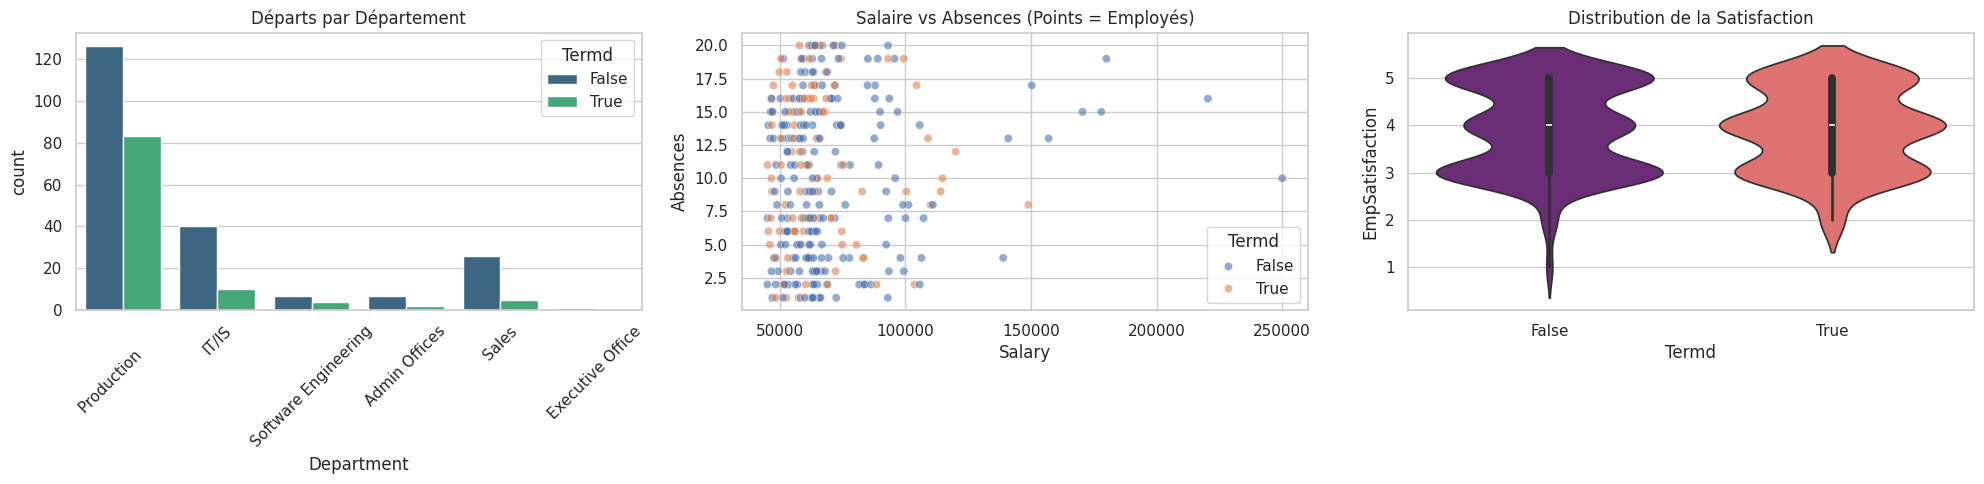

In [32]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=df, x='Department', hue='Termd', palette='viridis')
plt.xticks(rotation=45)
plt.title('Départs par Département')

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='Salary', y='Absences', hue='Termd', alpha=0.6)
plt.title('Salaire vs Absences (Points = Employés)')

plt.subplot(1, 3, 3)
sns.violinplot(data=df, x='Termd', y='EmpSatisfaction', palette='magma')
plt.title('Distribution de la Satisfaction')

plt.tight_layout()
plt.show()

## Keep EmpID only for identification

In [33]:

if "EmpID" in X.columns:
    emp_ids = X["EmpID"]
    X_model = X.drop(columns=["EmpID"])
else:
    X_model = X.copy()


## Detect column types

In [34]:

cat_cols = X_model.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_model.select_dtypes(exclude=["object"]).columns.tolist()

cat_cols, num_cols


(['Position',
  'State',
  'MaritalDesc',
  'RaceDesc',
  'Department',
  'RecruitmentSource',
  'LastPerformanceReview_Date'],
 ['MarriedID',
  'MaritalStatusID',
  'GenderID',
  'DeptID',
  'PerfScoreID',
  'FromDiversityJobFairID',
  'Salary',
  'PositionID',
  'HispanicLatino',
  'ManagerID',
  'PerformanceScore',
  'EngagementSurvey',
  'EmpSatisfaction',
  'SpecialProjectsCount',
  'DaysLateLast30',
  'Absences',
  'IsUSCitizen',
  'TenureYears'])

## Preprocessing pipelines

In [35]:

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess = ColumnTransformer([
    ("cat", categorical_pipeline, cat_cols),
    ("num", numeric_pipeline, num_cols)
])


## Train/Test split

In [36]:

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


## Model

In [37]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

comparison_results = []

for name, model in models.items():
    tracker = EmissionsTracker(project_name=name.replace(" ", "_"))
    current_pipeline = Pipeline(steps=[
        ('preprocessor', preprocess),
        ('classifier', model)
    ])

    tracker.start()
    current_pipeline.fit(X_train, y_train)
    emissions = tracker.stop()

    y_pred = current_pipeline.predict(X_test)
    y_proba = current_pipeline.predict_proba(X_test)[:, 1]

    comparison_results.append({
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba),
        "Émissions CO2 (mg)": emissions * 1000000
    })

df_compare = pd.DataFrame(comparison_results).sort_values(by="F1-Score", ascending=False)
display(df_compare)

[codecarbon WARNING @ 09:53:51] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 09:53:51] [setup] RAM Tracking...
[codecarbon INFO @ 09:53:51] [setup] CPU Tracking...
[codecarbon WARNING @ 09:53:51] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 09:53:51] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 09:53:51] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 09:53:51] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 09:53:51] [setup] GPU Tracking...
[codecarbon INFO @ 09:53:51] No GPU found.
[codecarbon INFO @ 09:53:51] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation mo

,Modèle,Accuracy,F1-Score,AUC,Émissions CO2 (mg)
0,Random Forest,0.809524,0.684211,0.795351,1.359483
1,Logistic Regression,0.777778,0.650000,0.816327,5.708564
2,Gradient Boosting,0.761905,0.615385,0.806689,1.731456


## Full pipeline

In [38]:

best_model = models[df_compare.iloc[0]["Modèle"]]

pipeline = Pipeline([
    ("prep", preprocess),
    ("model", best_model)
])


## Train model

In [39]:

pipeline.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Position', 'State',
                                                   'MaritalDesc', 'RaceDesc',
                                                   'Department',
                                                   'RecruitmentSource',
                                                   'LastPerformanceReview_Date']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['MarriedID',
                                                   'MaritalStatusID',
                                                   'GenderID', 'DeptID',
                                                   'PerfScoreID',
                                                   'FromDiversityJobFairID',
                                                   'Salary', 'PositionID',
                                                   'HispanicLatino',
                                                   'ManagerID',
                                                   'PerformanceScore',
                                                   'EngagementSurvey',
                                                   'EmpSatisfaction',
                                                   'SpecialProjectsCount',
                                                   'DaysLateLast30', 'Absences',
                                                   'IsUSCitizen',
                                                   'TenureYears'])])),
                ('model', RandomForestClassifier(random_state=42))])

## Evaluate model

In [40]:

proba = pipeline.predict_proba(X_test)
pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))


Accuracy: 0.8095238095238095
              precision    recall  f1-score   support

       False       0.83      0.90      0.86        42
        True       0.76      0.62      0.68        21

    accuracy                           0.81        63
   macro avg       0.80      0.76      0.77        63
weighted avg       0.81      0.81      0.80        63



## Attach EmpID to predictions

In [41]:

departure_prob = proba[:,1]

results = df.loc[X_test.index].copy()

results["Prediction"] = pred
results["DepartureProbability"] = departure_prob
results["DepartureProbability"] = results["DepartureProbability"] * 100

results["Real"] = y_test

results[["EmpID","DepartureProbability","Prediction","Real"]].head()


,EmpID,DepartureProbability,Prediction,Real
185,238e635694,46.0,False,True
34,e5c1b42898,65.0,True,False
310,6db404e5a7,25.0,False,False
139,a1e69834d4,12.0,False,False
150,cf06f44047,25.0,False,False


In [42]:
X_full = df.drop(columns=['Termd'])

all_probs = pipeline.predict_proba(X_full)[:, 1]

X_transformed = pipeline.named_steps['prep'].transform(X_full)

if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

features_names = pipeline.named_steps['prep'].get_feature_names_out()

model = pipeline.named_steps['model']

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
elif hasattr(model, "coef_"):
    importances = model.coef_[0]
else:
    raise ValueError("Modèle non compatible")

X_avg = X_transformed.mean(axis=0)

feature_details = []

for i in range(len(X_transformed)):
    diff_to_avg = X_transformed[i] * importances
    top_5_indices = diff_to_avg.argsort()[-5:][::-1]

    row_info = []
    for idx in top_5_indices:
        feat_name = features_names[idx]


        original_col = feat_name.split('__')[-1].split('_')[0]

        if original_col in df.columns:
            valeur_reelle = df.iloc[i][original_col]
            row_info.append(f"{feat_name} ({valeur_reelle})")
        else:
            row_info.append(f"{feat_name}")

    feature_details.append(row_info)

export_df = df.loc[X_full.index, ['EmpID', 'Termd']].copy()
export_df['Risque_%'] = (all_probs * 100).round(2)

cols_names = ['Facteur_1', 'Facteur_2', 'Facteur_3', 'Facteur_4', 'Facteur_5']
features_df = pd.DataFrame(feature_details, columns=cols_names, index=export_df.index)

final_export = pd.concat([export_df, features_df], axis=1)

final_export = final_export[final_export['Termd'] == 0].drop(columns=['Termd'])

final_export.sort_values(by='Risque_%', ascending=False, inplace=True)

final_export.to_excel("Audit_Attrition_Complet.xlsx", index=False)

print("Excel généré avec succès")
display(final_export.head(10))

✅ Excel généré avec succès


,EmpID,Risque_%,Facteur_1,Facteur_2,Facteur_3,Facteur_4,Facteur_5
190,a405e94f22,67.0,num__Salary (157000),num__TenureYears (14.093150684931507),num__Absences (13),num__PositionID (13),num__ManagerID (5)
34,e5c1b42898,65.0,num__Salary (62162),num__TenureYears (14.961643835616439),num__ManagerID (19),num__Absences (15),num__PositionID (20)
122,a62ea4a308,60.0,num__Salary (54828),num__TenureYears (14.30958904109589),num__ManagerID (22),num__Absences (13),num__PositionID (19)
3,2158e1eb1c,56.0,num__Salary (64991),num__TenureYears (18.202739726027396),num__ManagerID (16),num__Absences (15),num__PositionID (19)
54,c02db012f5,46.0,num__Salary (68051),num__TenureYears (15.668493150684931),num__PositionID (18),num__EngagementSurvey (4.13),num__ManagerID (2)
219,dded0c92ff,42.0,num__Salary (74226),num__TenureYears (13.964383561643835),num__ManagerID (12),num__Absences (14),num__PositionID (20)
165,b3206098b6,41.0,num__Salary (64738),num__TenureYears (13.849315068493151),num__ManagerID (16),num__PositionID (19),num__Absences (10)
66,56fe0b571d,39.0,num__Salary (101199),num__TenureYears (14.194520547945206),num__PositionID (24),num__ManagerID (10),num__Absences (8)
144,af285d72b6,37.0,num__Salary (105700),num__TenureYears (11.202739726027398),num__ManagerID (4),num__PositionID (8),num__EngagementSurvey (3.75)
183,ce96d2e212,36.0,num__Salary (62810),num__TenureYears (13.197260273972603),num__ManagerID (20),num__Absences (20),num__PositionID (19)
